In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import scipy

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.ticker as ticker

import os
import sys
sys.path.append('elchem_handy_V4_1')
import elchem_handy as pyfai

from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
from scipy.signal import savgol_filter

import impedance
from impedance.models.circuits import Randles, CustomCircuit
from impedance.models.circuits.fitting import circuit_elements, get_element_from_name, extract_circuit_elements, circuit_fit
from impedance.models.circuits.fitting import check_and_eval

from itertools import zip_longest

# import ipywidgets as widgets
# from ipywidgets import HBox, VBox
# from IPython.display import display

import matplotlib.pylab as pylab

small=14
middle=16
large=18
xlarge=20
xxlarge=22

params = {'figure.figsize': (8, 8),
          'font.size': middle,
          'legend.fontsize':middle,
         'axes.labelsize': xlarge,
         'axes.titlesize': large,
         'xtick.labelsize': middle,
         'ytick.labelsize':middle,
         'figure.autolayout' : True}
pylab.rcParams.update(params)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
path_IN=r'\\ELECTROLYZER\PEM-WE_measurements\2025'
sample=r'239_IV_IV IrOx series 0 sccm O2 15 sccm Ar'

path_OUT=path_IN+'\\'+sample+'\\exports'
if not os.path.exists(path_OUT):
    os.makedirs(path_OUT)

dataEL0,filelistEL0,filenamesEL0= pyfai.loadFilesMPT(folder=path_IN+'\\'+sample,wild = '*')

print(filenamesEL0)

area=4.62

['IV_Day1_procedure1_01_MB_C01.mpt', 'IV_Day1_procedure1_02_OCV_C01.mpt', 'IV_Day1_procedure1_03_SV_C01.mpt', 'IV_Day1_procedure1_04_OCV_C01.mpt', 'IV_Day1_procedure1_05_PEIS_C01.mpt', 'IV_Day1_procedure1_06_OCV_C01.mpt', 'IV_Day1_procedure1_07_CA_C01.mpt', 'IV_Day1_procedure1_08_OCV_C01.mpt', 'IV_Day1_procedure1_10_MB_C01.mpt', 'IV_Day1_procedure1_11_OCV_C01.mpt', 'IV_Day2_procedure1_01_MB_C01.mpt', 'IV_Day2_procedure1_02_OCV_C01.mpt', 'IV_Day2_procedure1_03_SV_C01.mpt', 'IV_Day2_procedure1_04_OCV_C01.mpt', 'IV_Day2_procedure1_05_PEIS_C01.mpt', 'IV_Day2_procedure1_06_OCV_C01.mpt', 'IV_Day2_procedure1_07_CA_C01.mpt', 'IV_Day2_procedure1_08_OCV_C01.mpt', 'IV_Day2_procedure1_10_MB_C01.mpt', 'IV_Day2_procedure1_11_OCV_C01.mpt', 'IV_Day3_procedure1_01_MB_C01.mpt', 'IV_Day3_procedure1_02_OCV_C01.mpt', 'IV_Day3_procedure1_03_SV_C01.mpt', 'IV_Day3_procedure1_04_OCV_C01.mpt', 'IV_Day3_procedure1_05_PEIS_C01.mpt', 'IV_Day3_procedure1_06_OCV_C01.mpt', 'IV_Day3_procedure1_07_CA_C01.mpt', 'IV_Day3

In [5]:
#SV, t=5,E=7,I=8
#CA, t=7,E=9,I=10
#MB, t=8,E=10,I=11
#IS 

In [6]:
%matplotlib widget
#SV comparison

Sday='all'

dataEL0F,filesEL0F,L0F=pyfai.selectEL(dataEL0,filenamesEL0,day="all",loop=[3],procedure='SV', EIS_E='all', plot='N', S=area)


fig = plt.figure()
ax = fig.add_subplot()

for i, file in enumerate(dataEL0F):
    if len(file)==0:
        continue
    ax.plot(file[:,8]/(area*1000),file[:,7], label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), frameon=False)    

ax.set_ylabel('Cell Voltage / V')
ax.set_xlabel('Current Density / mA cm$^{-2}$')
plt.savefig(path_OUT+'\\IV_curves.png', transparent=True,bbox_inches="tight")
plt.tight_layout()

TypeError: selectEL() missing 1 required positional argument: 'nr'

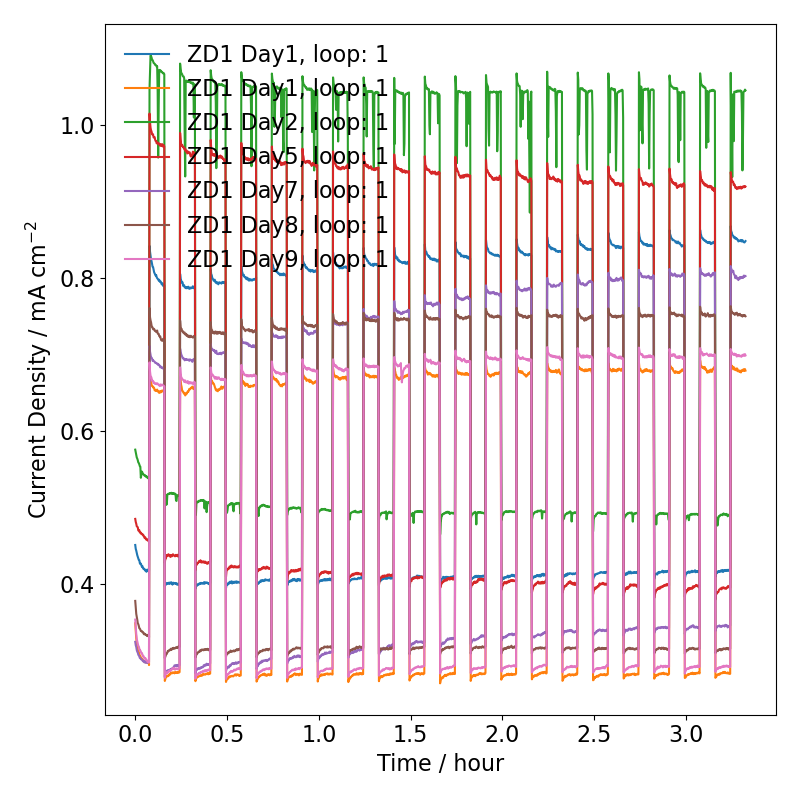

In [6]:
%matplotlib widget
#CA comparison

Sday='all'

dataEL0F,filesEL0F,L0F=pyfai.selectEL(dataEL0,filenamesEL0,day=[1,2,5,7,8,9,10,11,12,13,14],loop=[1],procedure='CA', EIS_E='all', plot='N', S=area)

fig = plt.figure()
ax = fig.add_subplot()

for i, file in enumerate(dataEL0F):
    if len(file)==0:
        continue
    ax.plot(file[:,7]/3600,file[:,10]/(area*1000), label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])

ax.legend(frameon=False)
ax.set_xlabel('Time / hour')
ax.set_ylabel('Current Density / mA cm$^{-2}$')
plt.savefig(path_OUT+'\\CA_curves.png', transparent=True,bbox_inches="tight")
plt.tight_layout()

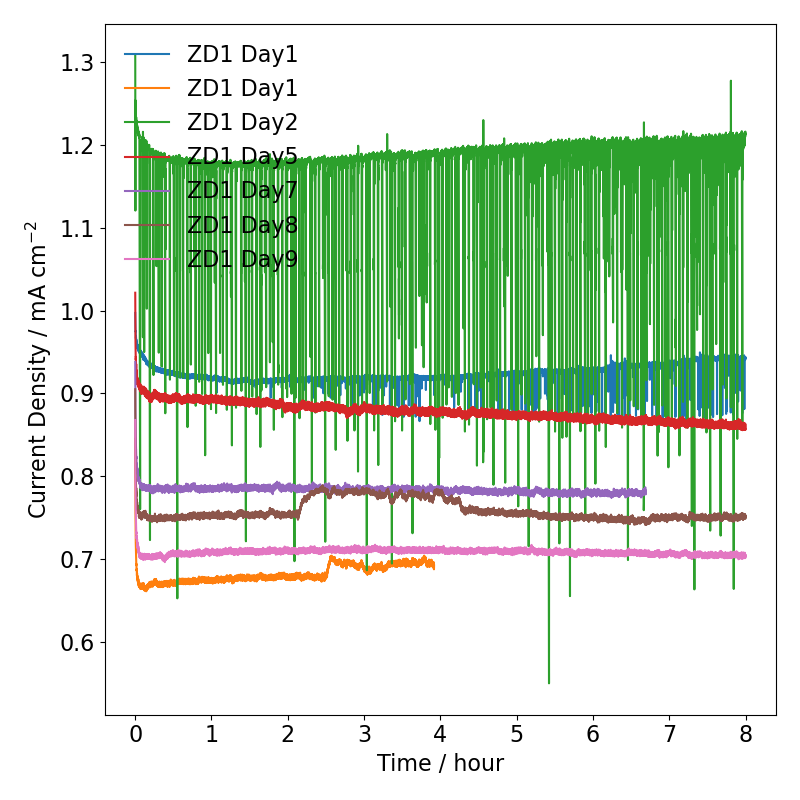

In [7]:
%matplotlib widget
#MB comparison

Sday='all'

dataEL0F,filesEL0F,L0F=pyfai.selectEL(dataEL0,filenamesEL0,day=[1,2,5,7,8,9,10,11,12,13,14],loop=[1],procedure='MB',seq=[10], EIS_E='all', plot='N', S=area)

fig = plt.figure()
ax = fig.add_subplot()

for i, file in enumerate(dataEL0F):
    if len(file)==0:
        continue
    ax.plot(file[4:,8]/3600,file[4:,11]/(area*1000), label=sample[0:3]+' '+filesEL0F[i][0:4])

ax.legend(frameon=False)
ax.set_xlabel('Time / hour')
ax.set_ylabel('Current Density / mA cm$^{-2}$')
plt.savefig(path_OUT+'\\MB_curves.png', transparent=True,bbox_inches="tight")
plt.tight_layout()

<>:20: SyntaxWarning: invalid escape sequence '\O'
<>:21: SyntaxWarning: invalid escape sequence '\O'
<>:23: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\O'
<>:20: SyntaxWarning: invalid escape sequence '\O'
<>:21: SyntaxWarning: invalid escape sequence '\O'
<>:23: SyntaxWarning: invalid escape sequence '\O'
<>:24: SyntaxWarning: invalid escape sequence '\O'
C:\Users\alexr\AppData\Local\Temp\ipykernel_648\2322502381.py:20: SyntaxWarning: invalid escape sequence '\O'
  ax.set_xlabel('Re Z / m$ \Omega$ ')
C:\Users\alexr\AppData\Local\Temp\ipykernel_648\2322502381.py:21: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel('-Im / m$ \Omega$ ')
C:\Users\alexr\AppData\Local\Temp\ipykernel_648\2322502381.py:23: SyntaxWarning: invalid escape sequence '\O'
  ax.set_xlabel('Re Z / m$ \Omega$ cm$^{-2} $')
C:\Users\alexr\AppData\Local\Temp\ipykernel_648\2322502381.py:24: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel('-Im / m$ \Om

[]


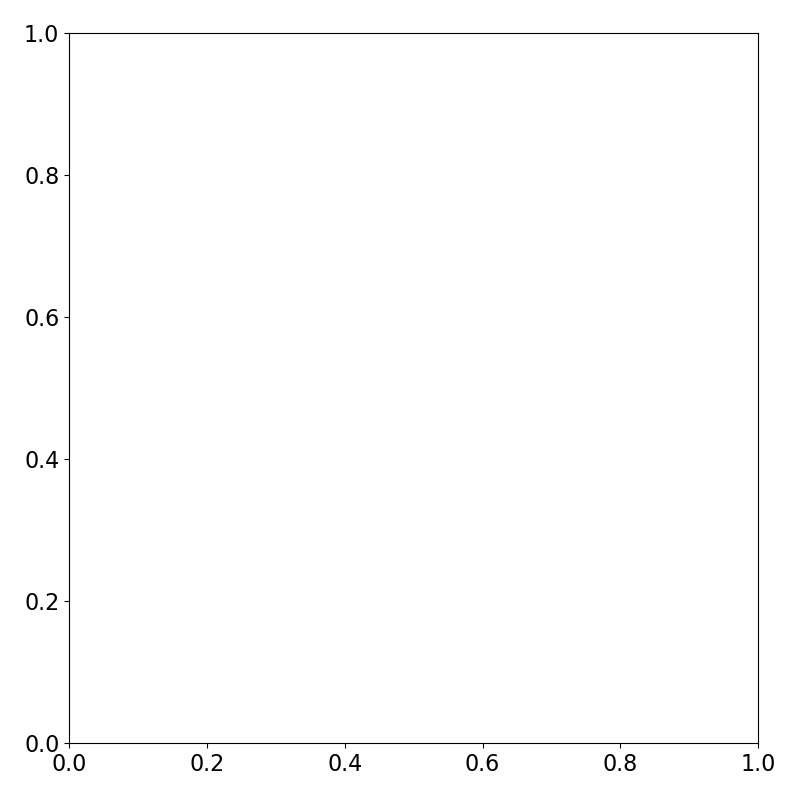

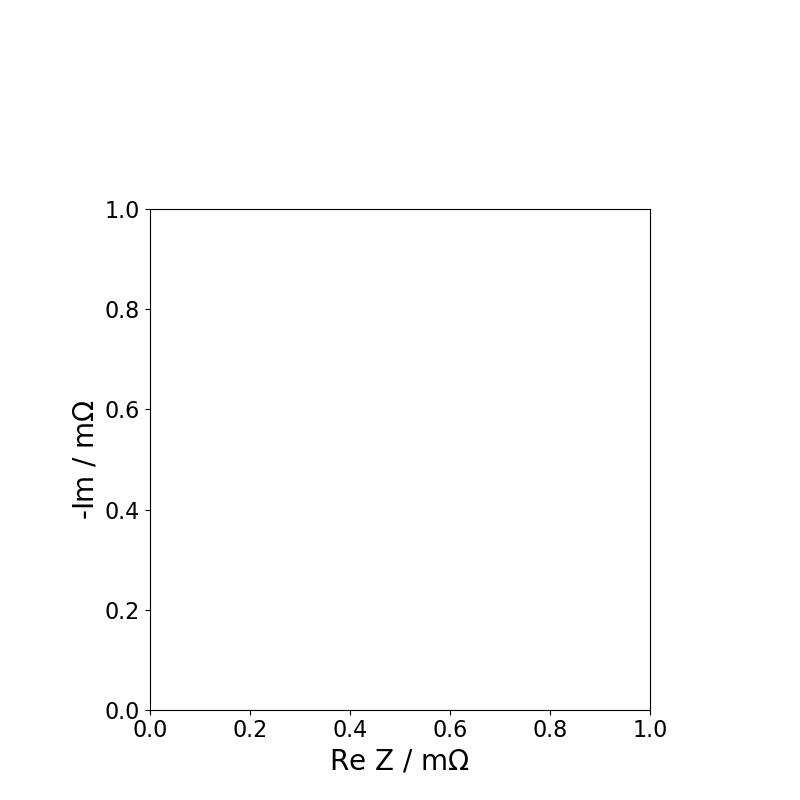

In [15]:
%matplotlib widget
#PEIS comparison

Sday='all'
EIS='all'
dataEL0F,filesEL0F,L0F=pyfai.selectEL(dataEL0,filenamesEL0,239,day=[1,2,3],loop=[1],procedure='IS', EIS_E=EIS, plot='Y', S=area,fR=[3E4,1])

fig = plt.figure()
ax = fig.add_subplot()
cm=1/2.54
# plt.rcParams['figure.figsize'] = [5*cm, 5*cm]
area=1
for i, file in enumerate(dataEL0F):
    if len(file)==0:
        continue
    ax.plot(file[:,1]*area*1000,file[:,2]*area*1000, label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])

ax.legend(frameon=False, bbox_to_anchor =(0.7, 1.6))
if area==1:
    ax.set_xlabel('Re Z / m$ \Omega$ ')
    ax.set_ylabel('-Im / m$ \Omega$ ')
else:
    ax.set_xlabel('Re Z / m$ \Omega$ cm$^{-2} $')
    ax.set_ylabel('-Im / m$ \Omega$ cm$^{-2} $')
ax.set_aspect('equal')
plt.savefig(path_OUT+'\\PEIS_curves.png', transparent=True,bbox_inches="tight")
plt.tight_layout()

<>:58: SyntaxWarning: invalid escape sequence '\O'
<>:59: SyntaxWarning: invalid escape sequence '\O'
<>:61: SyntaxWarning: invalid escape sequence '\O'
<>:62: SyntaxWarning: invalid escape sequence '\O'
<>:58: SyntaxWarning: invalid escape sequence '\O'
<>:59: SyntaxWarning: invalid escape sequence '\O'
<>:61: SyntaxWarning: invalid escape sequence '\O'
<>:62: SyntaxWarning: invalid escape sequence '\O'
C:\Users\alexr\AppData\Local\Temp\ipykernel_648\249156322.py:58: SyntaxWarning: invalid escape sequence '\O'
  ax.set_xlabel('Re Z / m$ \Omega$ ')
C:\Users\alexr\AppData\Local\Temp\ipykernel_648\249156322.py:59: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel('-Im / m$ \Omega$ ')
C:\Users\alexr\AppData\Local\Temp\ipykernel_648\249156322.py:61: SyntaxWarning: invalid escape sequence '\O'
  ax.set_xlabel('Re Z / m$ \Omega$ cm$^{-2} $')
C:\Users\alexr\AppData\Local\Temp\ipykernel_648\249156322.py:62: SyntaxWarning: invalid escape sequence '\O'
  ax.set_ylabel('-Im / m$ \Omega$

[]


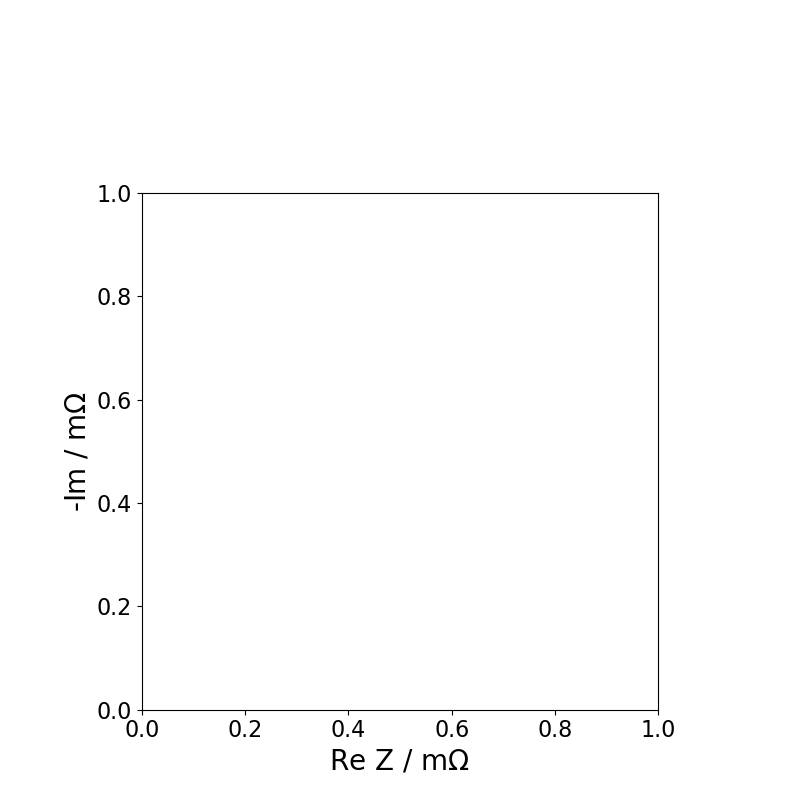

In [17]:
%matplotlib widget
#PEIS fitting

Sday='all'
EIS=[1.51]

f=[2E4,8]
# init=[0.0156, 0.032, 0.0099, 0.042, 0.0345, 0.838]
# bound=([0.01,0,0,0,0,0.6],[np.inf,np.inf,np.inf,np.inf,np.inf,1])
# cir='R_0-p(R_1-Ws_1,CPE_1)'

# init=[0.0156, 0.032, 0.0345, 0.838]
# bound=([0.01,0,0,0.6],[np.inf,np.inf,np.inf,1])
# cir='R_0-p(R_1,CPE_1)'

init=[0.02, 0.034, 0.09, 0.8, 0.005, 0.002, 0.96]
bound=([0.01,0,0,0.6,0,0,0.6],[np.inf,np.inf,1,1,np.inf,1,1])
cir='R_0-p(R_1,CPE_1)-p(R_2,CPE_2)'



area=1

dataEL0F,filesEL0F,L0F=pyfai.selectEL(dataEL0,filenamesEL0,239,day=[1,2,5,7,8,9,10,11,12,13,14],loop=[1,2,3],procedure='IS', EIS_E=EIS, plot='N', S=area, fR=f)

dataEL0F_fit,dataEL0F_par,dataEL0F_nam,L0_fit=pyfai.EIS_fit(dataEL0F,filesEL0F,L0F, circ=cir, initial=init, bound=bound)

fig = plt.figure()
ax = fig.add_subplot()
cm=1/2.54
# plt.rcParams['figure.figsize'] = [5*cm, 5*cm]
for i,data in enumerate(dataEL0F):
    if len(data)==0:
        continue
    if L0_fit[i]==3:
        A=len(data)//(L0_fit[i])
        ax.scatter(data[:A,1]*area*1000,data[:A,2]*area*1000,s=10, label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])
        ax.scatter(data[A:(2*A),1]*area*1000,data[A:(2*A),2]*area*1000,s=10, label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])
        ax.scatter(data[2*A:,1]*area*1000,data[2*A:,2]*area*1000,s=10, label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])
      
    elif L0_fit[i]==2:
        A=len(data)//(L0_fit[i])
        ax.scatter(data[:A,1]*area*1000,data[:A,2]*area*1000,s=10, label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])
        ax.scatter(data[A:,1]*area*1000,data[A:,2]*area*1000,s=10, label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])

    elif L0_fit[i]==1:
        ax.scatter(data[:,1]*area*1000,data[:,2]*area*1000,s=10, label=sample[0:3]+' '+filesEL0F[i][0:4]+', loop: '+str(L0F)[1:-1])
    
plt.gca().set_prop_cycle(None)
for i,fit in enumerate(dataEL0F_fit):
    ax.plot(fit[0]*area*1000,fit[1]*area*1000, label=sample[0:3]+' fit')
        
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), frameon=False, bbox_to_anchor =(0.5, 1.4))

if area==1:
    ax.set_xlabel('Re Z / m$ \Omega$ ')
    ax.set_ylabel('-Im / m$ \Omega$ ')
else:
    ax.set_xlabel('Re Z / m$ \Omega$ cm$^{-2} $')
    ax.set_ylabel('-Im / m$ \Omega$ cm$^{-2} $')
ax.set_aspect('equal')
plt.savefig(path_OUT+'\\PEIS_curves_fit.png', transparent=True,bbox_inches="tight")
plt.tight_layout()

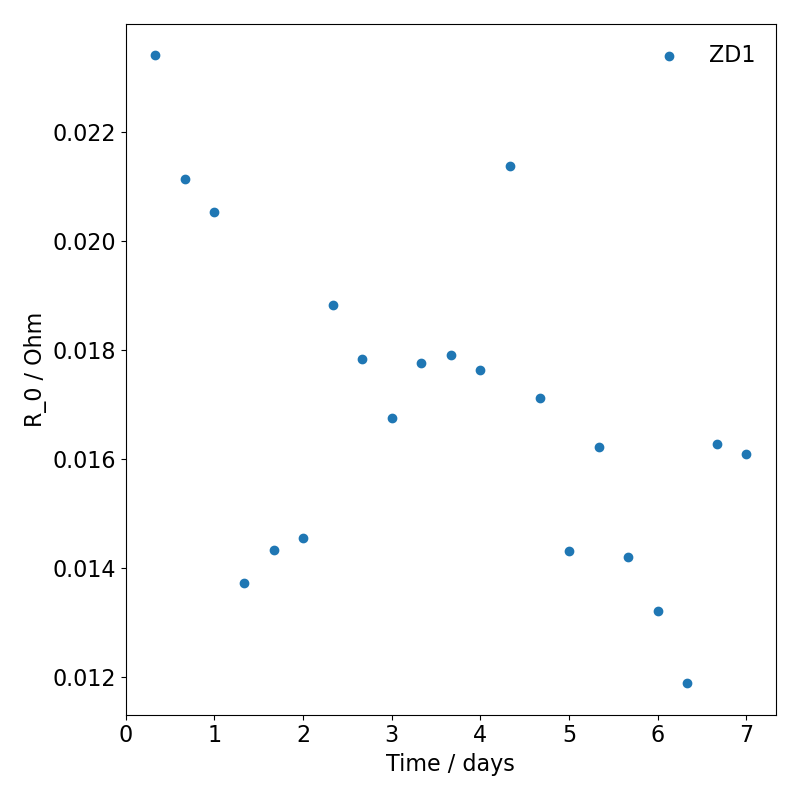

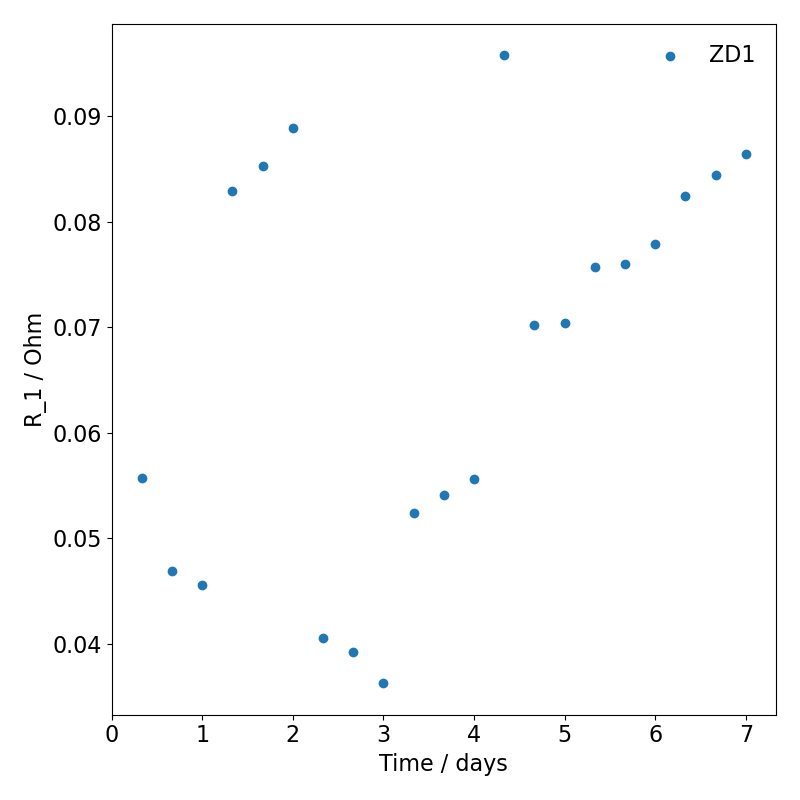

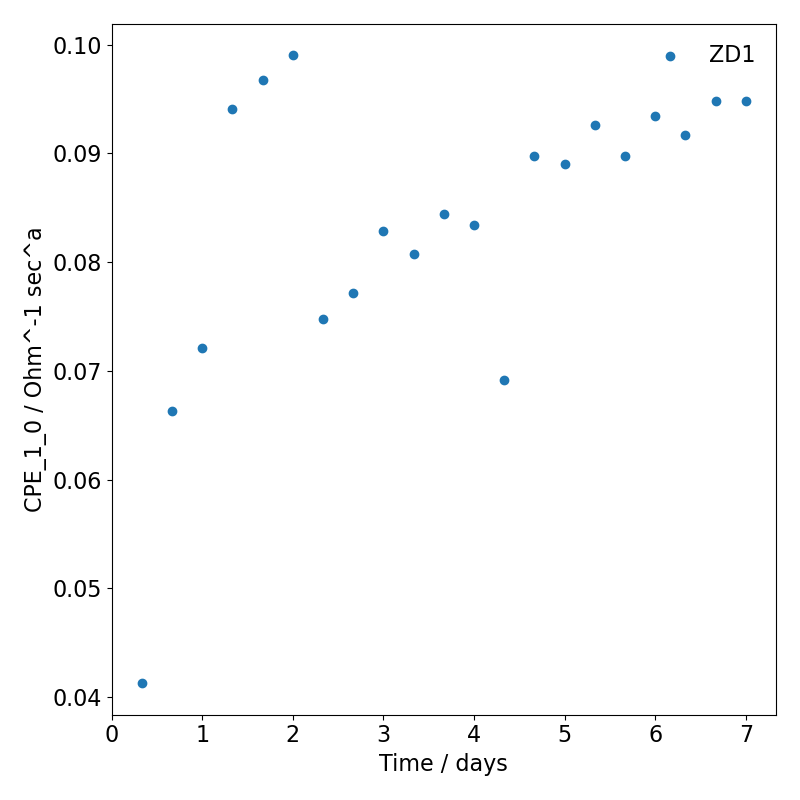

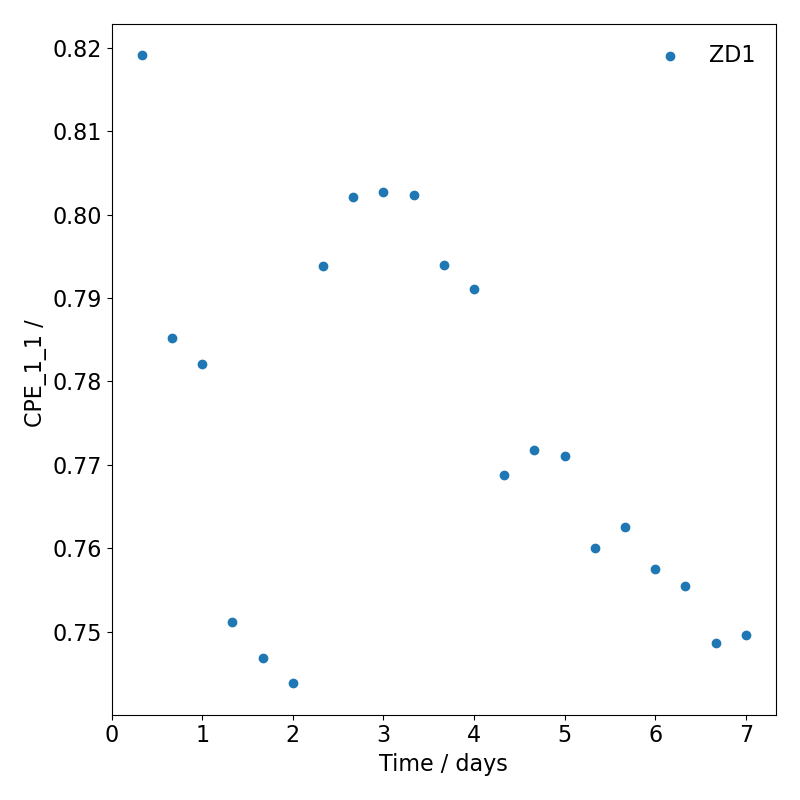

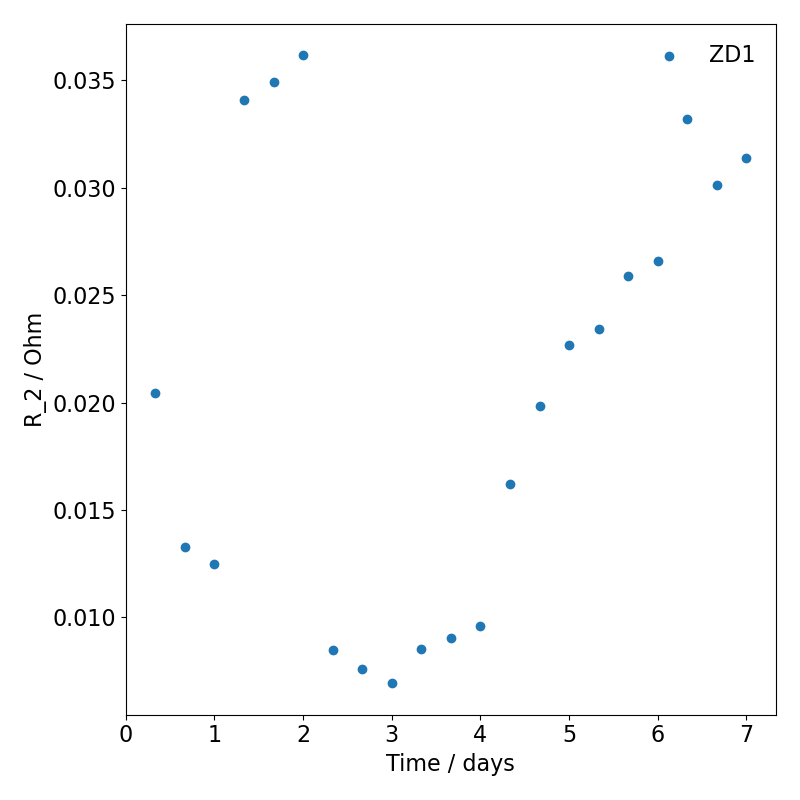

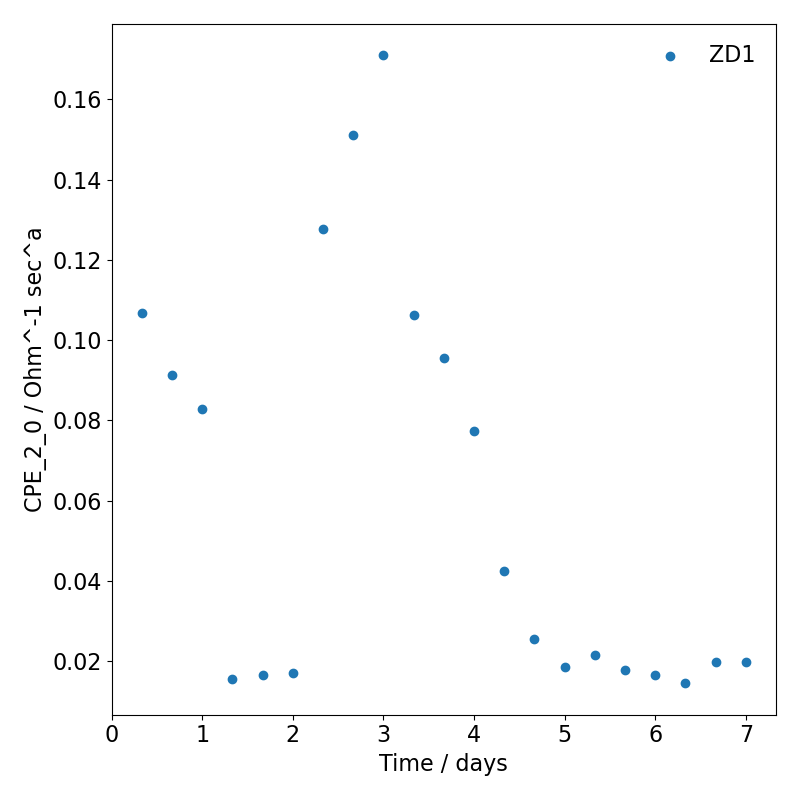

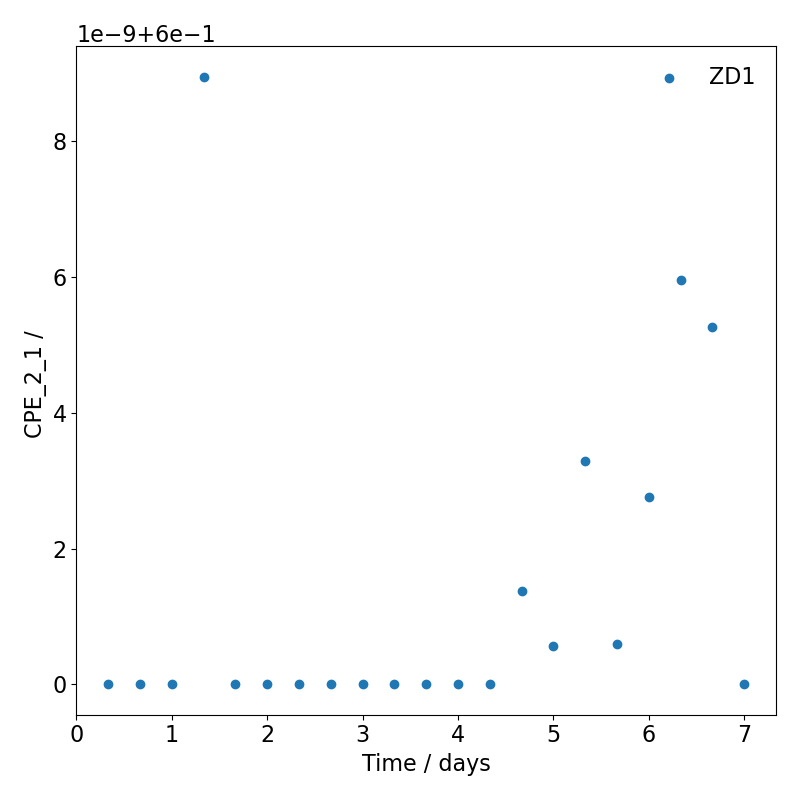

In [22]:
%matplotlib widget

EIS_par={}

for param, name in zip(dataEL0F_par, dataEL0F_nam):
    for par,nam in zip(param, name[0]):
        if nam in EIS_par.keys():
            EIS_par[nam].append(par)
        else:
            EIS_par.update({nam : [par]})
            
for i, key in enumerate(EIS_par.keys()):
    fig = plt.figure()
    ax = fig.add_subplot()
    time=(np.arange(1,sum(L0_fit)+1)/3).tolist()
    ax.scatter(time,EIS_par[key], label=sample[0:3])
    ax.legend(frameon=False) 
    if area==1:
        ax.set_xlabel('Time / days')
        ax.set_ylabel(dataEL0F_nam[1][0][i]+ ' / ' + dataEL0F_nam[1][1][i])
    else:
        ax.set_xlabel('Time / days')
        ax.set_ylabel(dataEL0F_nam[1][0][i]+ ' / ' + dataEL0F_nam[1][1][i]+ 'cm$^{-2}$')
    plt.savefig(path_OUT+'\\'+dataEL0F_nam[1][0][i]+'.png', transparent=True,bbox_inches="tight")
    plt.tight_layout()